In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import xgboost as xgb
import optuna
import shap

import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
df = pd.read_csv("Data/data_processed.csv")

In [3]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.value_counts())

(283726, 30)
Class
0    283253
1       473
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(226980, 30)
(56746, 30)


In [5]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("scale_pos_weight =", scale_pos_weight)

Negative: 226602
Positive: 378
scale_pos_weight = 599.4761904761905


In [6]:
def objective(trial):

    params = {

        "objective": "binary:logistic",
        "eval_metric": "aucpr",

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 10
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "gamma": trial.suggest_float(
            "gamma", 0, 5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0, 5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0, 5
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 600
        ),

        # để Optuna tìm trọng số fraud
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            1,
            50
        ),

        "random_state": 42,
        "tree_method": "hist",
        "n_jobs": -1
    }


    model = xgb.XGBClassifier(**params)


    model.fit(
        X_train,
        y_train,
        verbose=False
    )


    prob = model.predict_proba(
        X_test
    )[:,1]


    # threshold cao hơn => ưu tiên precision
    threshold = 0.5


    pred = (
        prob >= threshold
    ).astype(int)


    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )


    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )


    # phạt nếu recall quá thấp
    if recall < 0.5:
        precision *= 0.5


    return precision

In [7]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-06-29 20:22:21,194] A new study created in memory with name: no-name-bbdfa686-369d-4345-b3dc-699a57f693f3
Best trial: 0. Best value: 0.936709:   2%|▏         | 1/50 [00:10<08:47, 10.76s/it]

[I 2026-06-29 20:22:31,951] Trial 0 finished with value: 0.9367088607594937 and parameters: {'learning_rate': 0.13647122663424358, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.96136496165409, 'colsample_bytree': 0.7035159302599656, 'gamma': 0.11156578285693997, 'reg_alpha': 4.327828072258802, 'reg_lambda': 0.9912939703961338, 'n_estimators': 469, 'scale_pos_weight': 34.519860630265946}. Best is trial 0 with value: 0.9367088607594937.


Best trial: 0. Best value: 0.936709:   4%|▍         | 2/50 [00:24<10:01, 12.54s/it]

[I 2026-06-29 20:22:45,737] Trial 1 finished with value: 0.8604651162790697 and parameters: {'learning_rate': 0.25095302112519396, 'max_depth': 8, 'min_child_weight': 9, 'subsample': 0.830684419739359, 'colsample_bytree': 0.8028591668771864, 'gamma': 4.360975590812341, 'reg_alpha': 4.478929051077442, 'reg_lambda': 0.32977983497629815, 'n_estimators': 456, 'scale_pos_weight': 39.98948823176661}. Best is trial 0 with value: 0.9367088607594937.


Best trial: 0. Best value: 0.936709:   6%|▌         | 3/50 [00:31<07:46,  9.93s/it]

...

[I 2026-06-29 20:27:38,102] Trial 47 finished with value: 0.948051948051948 and parameters: {'learning_rate': 0.11183741101179415, 'max_depth': 8, 'min_child_weight': 4, 'subsample': 0.9407630373443001, 'colsample_bytree': 0.6841765992323451, 'gamma': 1.5261566516743093, 'reg_alpha': 0.3208758293329276, 'reg_lambda': 1.7868842763423374, 'n_estimators': 455, 'scale_pos_weight': 10.581265951737926}. Best is trial 19 with value: 0.9864864864864865.


Best trial: 19. Best value: 0.986486:  98%|█████████▊| 49/50 [05:26<00:09,  9.01s/it]

[I 2026-06-29 20:27:48,005] Trial 48 finished with value: 0.948051948051948 and parameters: {'learning_rate': 0.03475270693433631, 'max_depth': 6, 'min_child_weight': 2, 'subsample': 0.7900375765328724, 'colsample_bytree': 0.7503508952680715, 'gamma': 1.20732333570494, 'reg_alpha': 3.5504986920237918, 'reg_lambda': 1.073129722871615, 'n_estimators': 572, 'scale_pos_weight': 4.652939265038535}. Best is trial 19 with value: 0.9864864864864865.


Best trial: 19. Best value: 0.986486: 100%|██████████| 50/50 [05:32<00:00,  6.66s/it]

[I 2026-06-29 20:27:53,950] Trial 49 finished with value: 0.8902439024390244 and parameters: {'learning_rate': 0.1432686824110544, 'max_depth': 10, 'min_child_weight': 1, 'subsample': 0.9853022160790801, 'colsample_bytree': 0.7732501975429922, 'gamma': 3.5882513378645804, 'reg_alpha': 0.5704755801924567, 'reg_lambda': 2.1165497633354087, 'n_estimators': 441, 'scale_pos_weight': 19.068403150092646}. Best is trial 19 with value: 0.9864864864864865.


In [8]:
best_params = study.best_params
print(study.best_value)
print(best_params)

0.9864864864864865
{'learning_rate': 0.21011240334148562, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.7793642600971756, 'colsample_bytree': 0.893344561183844, 'gamma': 1.4879019485650942, 'reg_alpha': 1.2919113379835288, 'reg_lambda': 1.1857325865170008, 'n_estimators': 416, 'scale_pos_weight': 12.25366579128679}


In [9]:
model = xgb.XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)


model.fit(
    X_train,
    y_train,
    verbose=True
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.893344561183844, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=1.4879019485650942, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.21011240334148562,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=416, n_jobs=-1,
              num_parallel_tree=None, ...)

In [10]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [11]:
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("PR AUC   :", average_precision_score(y_test, y_prob))

Accuracy : 0.9995946850879357
Precision: 0.9864864864864865
Recall   : 0.7684210526315789
F1 Score : 0.863905325443787
ROC AUC  : 0.970060824865822
PR AUC   : 0.8326818176979379


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.77      0.86        95

    accuracy                           1.00     56746
   macro avg       0.99      0.88      0.93     56746
weighted avg       1.00      1.00      1.00     56746



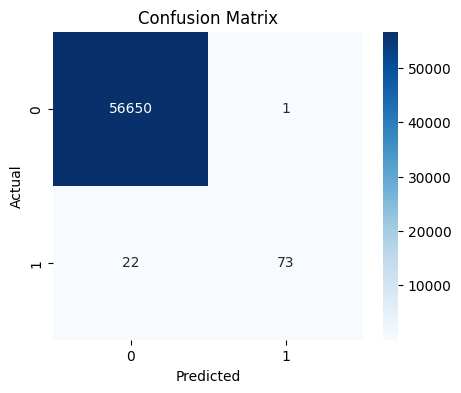

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
14,V14,0.470771
10,V10,0.077723
12,V12,0.047075
17,V17,0.045841
4,V4,0.031695
7,V7,0.022615
19,V19,0.019431
8,V8,0.018804
13,V13,0.018713
3,V3,0.016114


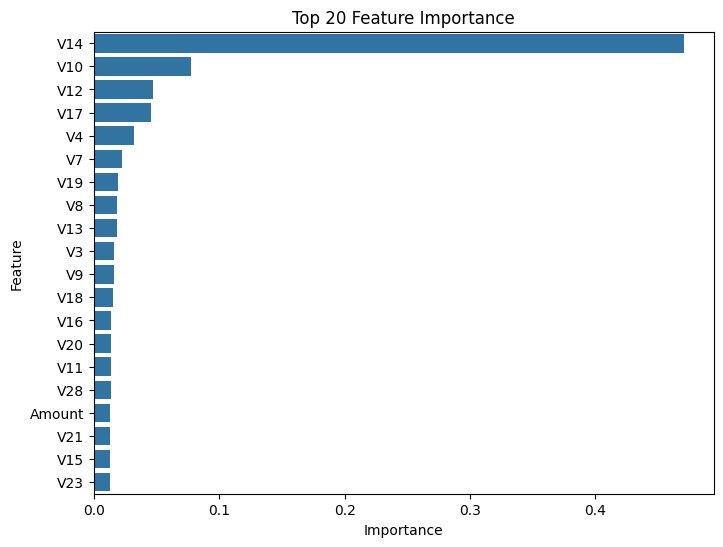

In [15]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance")

plt.show()

In [16]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

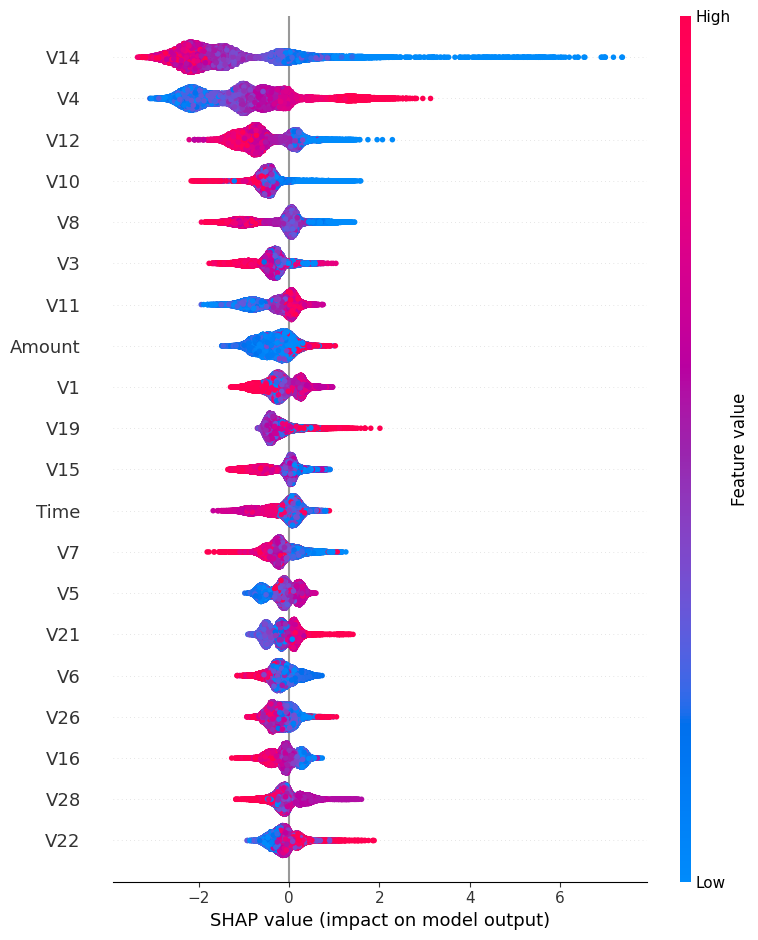

In [17]:
shap.summary_plot(
    shap_values,
    X_test
)

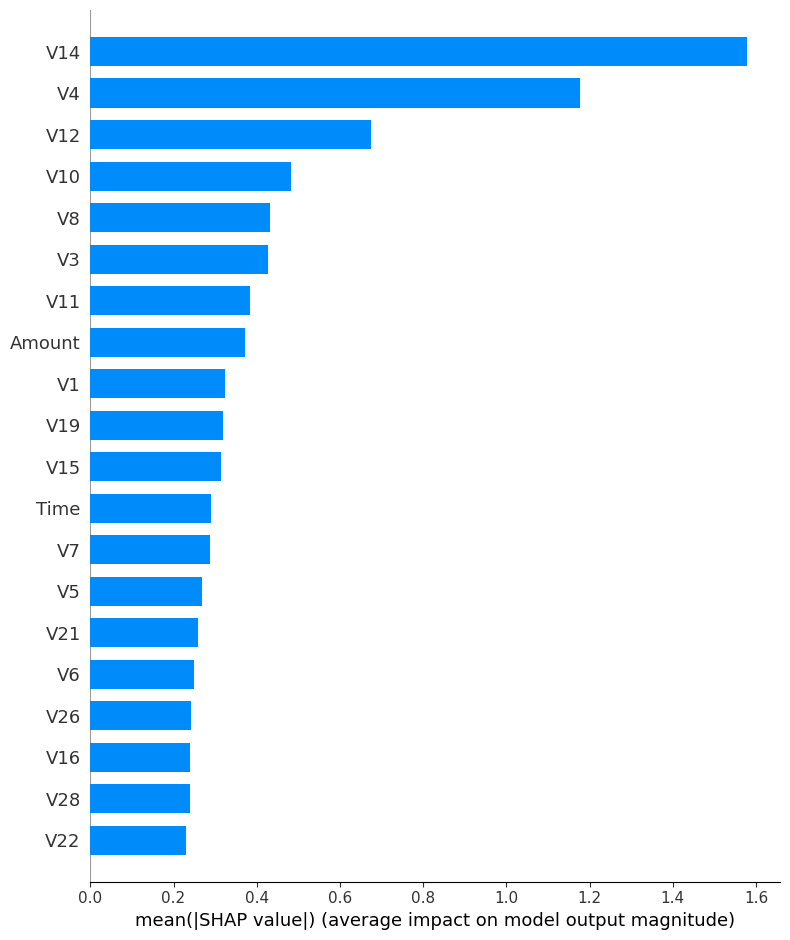

In [18]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [19]:
sample = 0

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[sample],
    X_test.iloc[sample]
)

In [ ]:
thresholds = np.arange(
    0.01,
    1.00,
    0.01
)


results = []


for t in thresholds:

    y_pred_t = (
        y_prob >= t
    ).astype(int)


    acc = accuracy_score(
        y_test,
        y_pred_t
    )

    precision = precision_score(
        y_test,
        y_pred_t,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_t,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_t,
        zero_division=0
    )


    results.append(
        [
            t,
            acc,
            precision,
            recall,
            f1
        ]
    )



threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)


# lọc threshold có Precision và Recall đều > 0.8
good_thresholds = threshold_df[
    (threshold_df["Precision"] >= 0.8) &
    (threshold_df["Recall"] >= 0.8)
]


# lấy 10 giá trị tốt nhất theo F1
top10 = good_thresholds.sort_values(
    by="F1",
    ascending=False
).head(10)


top10

,Threshold,Accuracy,Precision,Recall,F1
28,0.29,0.999524,0.904762,0.800000,0.849162
27,0.28,0.999507,0.894118,0.800000,0.844444
26,0.27,0.999489,0.883721,0.800000,0.839779
25,0.26,0.999471,0.873563,0.800000,0.835165
20,0.21,0.999454,0.855556,0.810526,0.832432
19,0.20,0.999436,0.846154,0.810526,0.827957
24,0.25,0.999436,0.853933,0.800000,0.826087
22,0.23,0.999436,0.853933,0.800000,0.826087
23,0.24,0.999436,0.853933,0.800000,0.826087
21,0.22,0.999436,0.853933,0.800000,0.826087
